# Фаза 2: EDA & Временной анализ — recsys-hm

Цель ноутбука — не общее знакомство с данными (это уже сделано в scratch-разведке),
а ответ на конкретные вопросы, которые определяют архитектурные решения следующих фаз:

1. Распределение транзакций по времени — сезонность, аномалии
2. Активные покупатели по периодам — хватит ли данных на valid/test
3. Repeat-purchase rate — какой должна быть длина test-периода
4. Long-tail товаров — насколько скошены продажи
5. Аномальные покупатели — где порог отсечки выбросов
6. Cold start — сколько холодных юзеров/товаров попадёт в test
7. Согласованность цены во времени — статична или динамична
8. Возраст vs категория товара — ценность возраста как признака
9. Тренд каналов продаж во времени — стабильность sales_channel_id

Результат — обоснованные `train_end` / `valid_end` / `test_end` для `configs/config.yaml`.

Работаем на processed Parquet (`data/processed/`), не на сырых CSV — типы и customer_idx
уже готовы из `src/data/loader.py`.


In [1]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

DATA_DIR = Path("../data/processed")

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (14, 5)

In [2]:
articles = pl.read_parquet(DATA_DIR / "articles.parquet")
customers = pl.read_parquet(DATA_DIR / "customers.parquet")
transactions = pl.read_parquet(DATA_DIR / "transactions_train.parquet")

print(f"articles:     {articles.shape}")
print(f"customers:    {customers.shape}")
print(f"transactions: {transactions.shape}")
print(f"\nДиапазон дат: {transactions['t_dat'].min()} — {transactions['t_dat'].max()}")

articles:     (105542, 25)
customers:    (1371980, 7)
transactions: (31788324, 5)

Диапазон дат: 2018-09-20 — 2020-09-22


## 1. Распределение транзакций по времени

Смотрим на объём продаж по дням — ищем сезонность, аномальные всплески/провалы,
общий тренд за 2 года. Это определяет, какие периоды безопасно использовать
как границы train/valid/test (не разрезать посреди аномального пика).

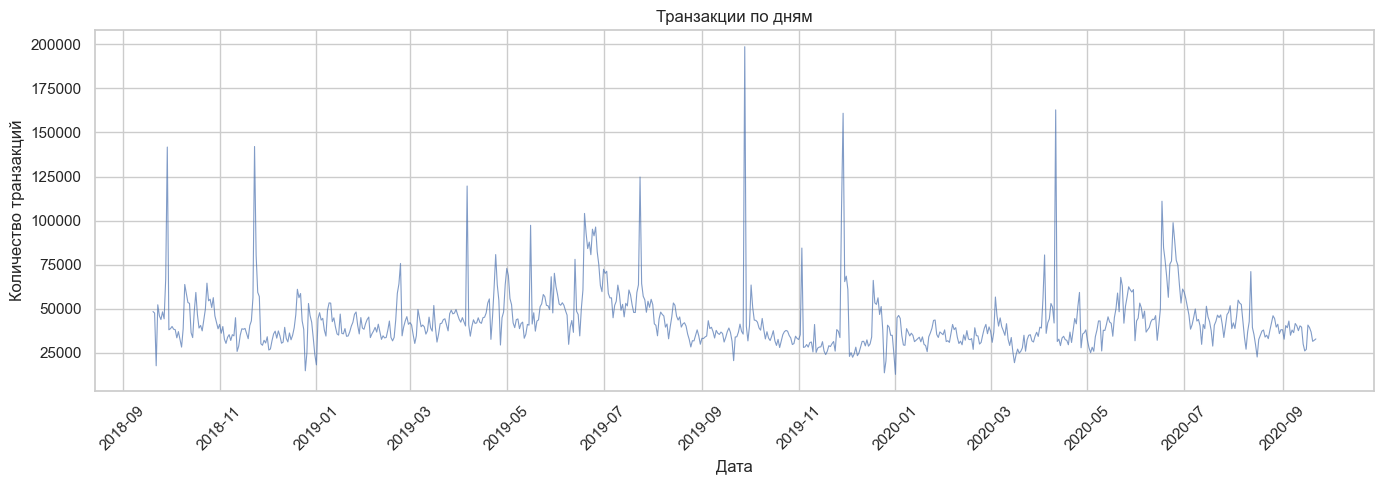

In [3]:
daily = (
    transactions
    .group_by("t_dat")
    .agg(pl.len().alias("n_transactions"))
    .sort("t_dat")
)
daily_pd = daily.to_pandas()

fig, ax = plt.subplots()
sns.lineplot(data=daily_pd, x="t_dat", y="n_transactions", linewidth=0.8, alpha=0.7, ax=ax)
ax.set_title("Транзакции по дням")
ax.set_xlabel("Дата")
ax.set_ylabel("Количество транзакций")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

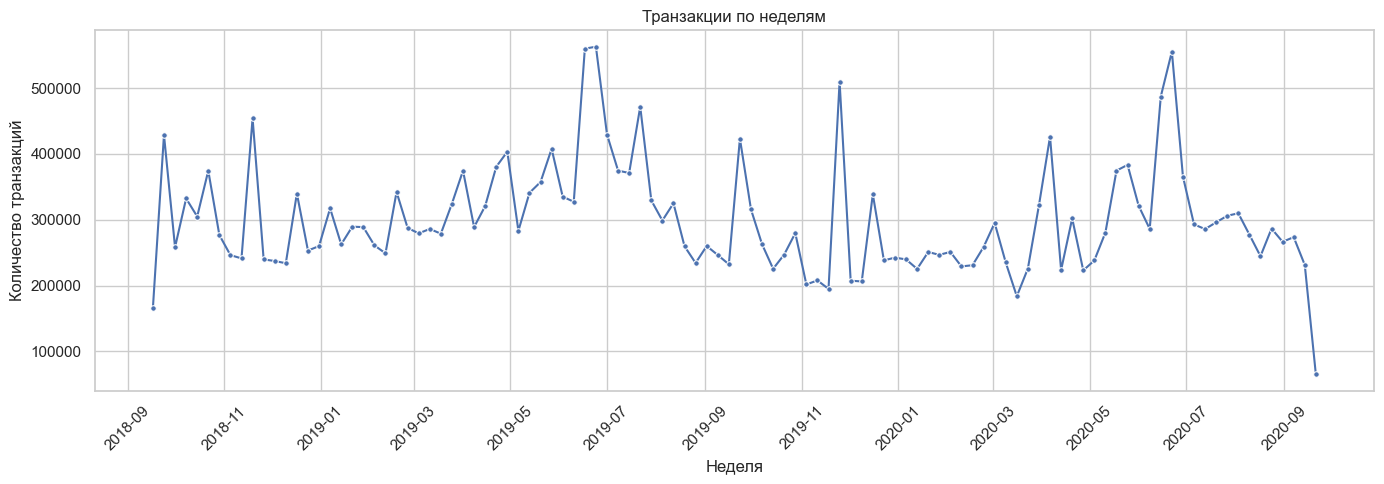

In [4]:
# Та же картина, сглаженная по неделям — меньше шума, виднее тренд и сезонность
weekly = (
    transactions
    .with_columns(pl.col("t_dat").dt.truncate("1w").alias("week"))
    .group_by("week")
    .agg(pl.len().alias("n_transactions"))
    .sort("week")
)
weekly_pd = weekly.to_pandas()

fig, ax = plt.subplots()
sns.lineplot(data=weekly_pd, x="week", y="n_transactions", marker="o", markersize=4, ax=ax)
ax.set_title("Транзакции по неделям")
ax.set_xlabel("Неделя")
ax.set_ylabel("Количество транзакций")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
# Топ-10 дней по объёму — проверяем, не аномалия ли это (Black Friday, сбой и т.п.)
daily.sort("n_transactions", descending=True).head(10)

t_dat,n_transactions
date,u32
2019-09-28,198622
2020-04-11,162799
2019-11-29,160875
2018-11-23,142018
2018-09-29,141700
2019-07-24,124683
2019-04-06,119601
2020-06-17,110981
2019-11-28,106257


**Вывод по разделу 1:** В топ-10 дней по объёму продаж чётко видна повторяющаяся
сезонность — **Black Friday** (2019-11-29 и 2018-11-23, оба попадают в топ с объёмом
в 1.4-2× выше обычного дня) и **конец сентября** (2019-09-28 — абсолютный максимум,
2018-09-29 тоже в топе). Это системная, не случайная сезонность.

Важно: наш датасет заканчивается **2020-09-22** — ровно в зоне, где в 2018 и 2019 годах
исторически были пики активности. При выборе test-периода это нужно учитывать —
последние недели датасета могут быть нетипично активными по сравнению со "средним"
периодом года.

## 2. Активные покупатели по периодам

Проверяем, хватит ли уникальных покупателей в потенциальных valid/test окнах
для статистически надёжной оценки метрик.

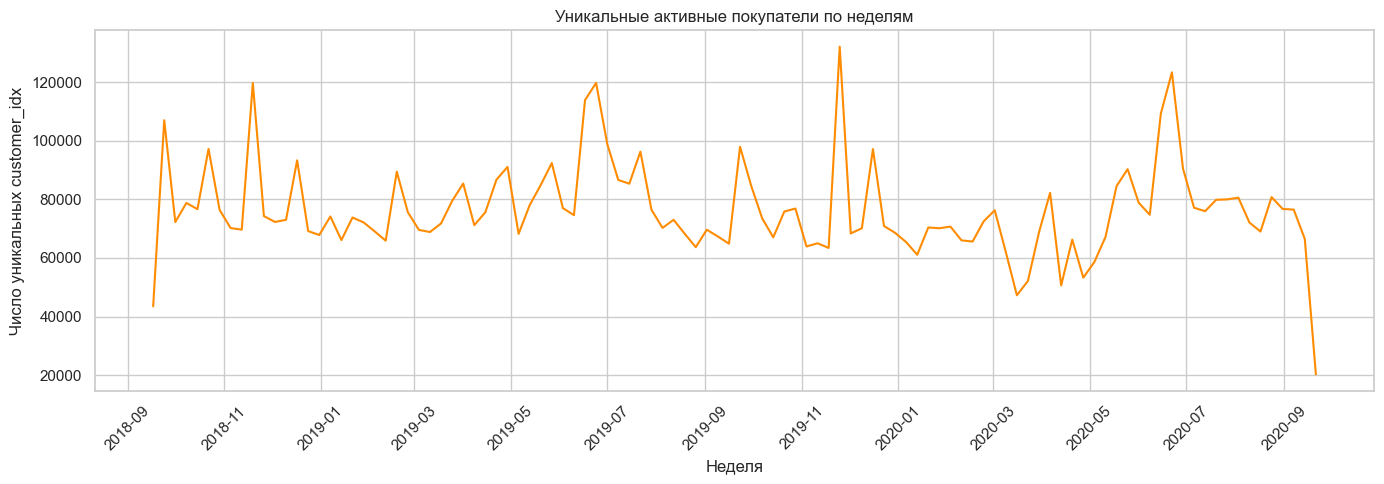

In [6]:
weekly_customers = (
    transactions
    .with_columns(pl.col("t_dat").dt.truncate("1w").alias("week"))
    .group_by("week")
    .agg(pl.col("customer_idx").n_unique().alias("n_active_customers"))
    .sort("week")
)
weekly_customers_pd = weekly_customers.to_pandas()

fig, ax = plt.subplots()
sns.lineplot(data=weekly_customers_pd, x="week", y="n_active_customers", color="darkorange", ax=ax)
ax.set_title("Уникальные активные покупатели по неделям")
ax.set_xlabel("Неделя")
ax.set_ylabel("Число уникальных customer_idx")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [7]:
# Сколько уникальных покупателей в последних N днях датасета — кандидаты на test-период
for n_days in [3, 7, 14, 21, 28]:
    cutoff = transactions["t_dat"].max()
    window_start = cutoff.__class__.fromordinal(cutoff.toordinal() - n_days)
    n_customers = (
        transactions
        .filter(pl.col("t_dat") > window_start)
        .select(pl.col("customer_idx").n_unique())
        .item()
    )
    n_transactions = transactions.filter(pl.col("t_dat") > window_start).height
    print(f"Последние {n_days:>2} дней: {n_customers:>7} уникальных покупателей, {n_transactions:>8} транзакций")

Последние  3 дней:   28845 уникальных покупателей,    96485 транзакций
Последние  7 дней:   68984 уникальных покупателей,   240311 транзакций
Последние 14 дней:  128333 уникальных покупателей,   495552 транзакций
Последние 21 дней:  182321 уникальных покупателей,   760209 транзакций
Последние 28 дней:  233174 уникальных покупателей,  1043390 транзакций


**Вывод по разделу 2:** Даже минимальное окно в 7 дней даёт ~69 тыс. уникальных
покупателей и 240 тыс. транзакций — этого более чем достаточно для надёжной оценки
метрик (Recall@K, NDCG@K не будут "шуметь" на выборке такого размера). Уже 14 дней
дают 128 тыс. покупателей. С точки зрения **объёма** данных test-период от 7 до 14 дней
уже достаточен — вопрос длины теперь упирается не в объём, а в repeat-purchase
поведение (раздел 3).

## 3. Repeat-purchase rate

Смотрим, сколько дней в среднем проходит между покупками одного и того же
покупателя — это подсказывает минимально осмысленную длину test-периода.

In [8]:
purchase_gaps = (
    transactions
    .select(["customer_idx", "t_dat"])
    .unique()
    .sort(["customer_idx", "t_dat"])
    .with_columns(
        pl.col("t_dat").diff().over("customer_idx").dt.total_days().alias("gap_days")
    )
    .drop_nulls("gap_days")
)

print(purchase_gaps["gap_days"].describe())

shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 7.717898e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 48.256015  │
│ std        ┆ 71.682626  │
│ min        ┆ 1.0        │
│ 25%        ┆ 7.0        │
│ 50%        ┆ 22.0       │
│ 75%        ┆ 58.0       │
│ max        ┆ 731.0      │
└────────────┴────────────┘


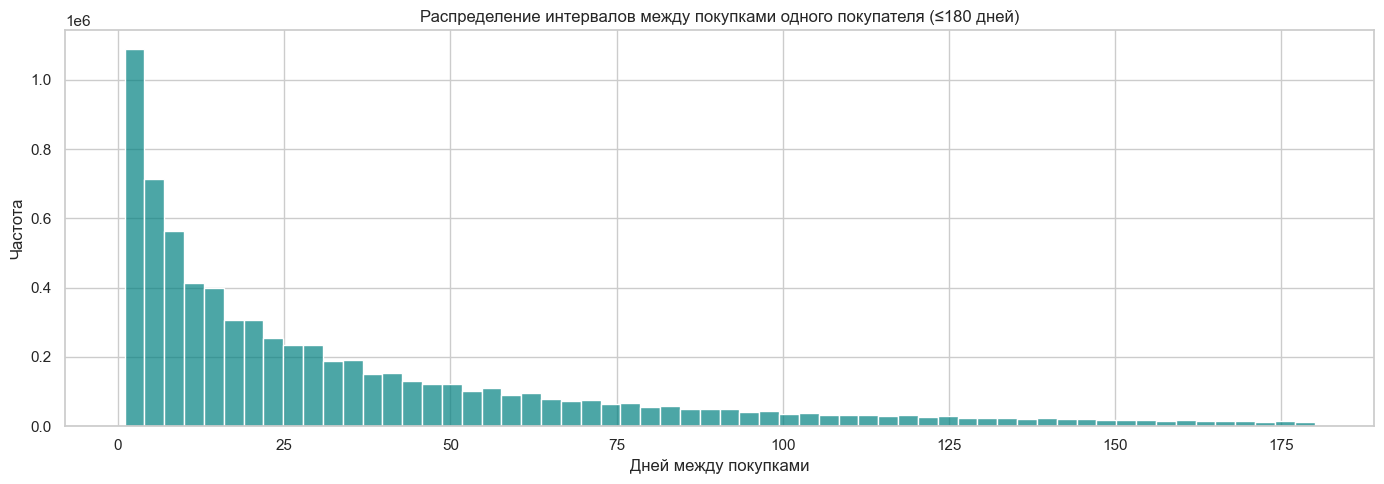

In [9]:
fig, ax = plt.subplots()
# отсекаем экстремальный хвост для читаемости гистограммы
gaps_clipped = purchase_gaps.filter(pl.col("gap_days") <= 180)["gap_days"].to_pandas()
sns.histplot(gaps_clipped, bins=60, color="teal", alpha=0.7, ax=ax)
ax.set_title("Распределение интервалов между покупками одного покупателя (≤180 дней)")
ax.set_xlabel("Дней между покупками")
ax.set_ylabel("Частота")
plt.tight_layout()
plt.show()

In [10]:
quantiles = [0.25, 0.5, 0.75, 0.9]
for q in quantiles:
    val = purchase_gaps["gap_days"].quantile(q)
    print(f"  {int(q*100)}-й перцентиль: {val:.0f} дней")

  25-й перцентиль: 7 дней
  50-й перцентиль: 22 дней
  75-й перцентиль: 58 дней
  90-й перцентиль: 124 дней


**Вывод по разделу 3:** Медианный интервал между покупками одного и того же
покупателя — **22 дня** (25-й перцентиль: 7 дней, 75-й: 58 дней, 90-й: 124 дня).
Типичный покупатель возвращается за новой покупкой примерно раз в 3 недели.

Это значит: test-окно короче 7-14 дней поймает только самых частых покупателей
(нижний квартиль), а **половина типичных покупателей с интервалом 22+ дня не успеет
вернуться** в узкое окно — для них не будет "правильного ответа" для оценки метрик.
Разумная длина test-периода — **не короче 14-21 дня**, чтобы поймать медианное
поведение.

## 4. Long-tail товаров

Насколько скошено распределение продаж между товарами — небольшая доля хитов
даёт основной объём, или продажи размазаны равномернее.

In [11]:
article_sales = (
    transactions
    .group_by("article_id")
    .agg(pl.len().alias("n_sales"))
    .sort("n_sales", descending=True)
)

article_sales.head(10)

article_id,n_sales
i32,u32
706016001,50287
706016002,35043
372860001,31718
610776002,30199
759871002,26329
464297007,25025
372860002,24458
610776001,22451
399223001,22236


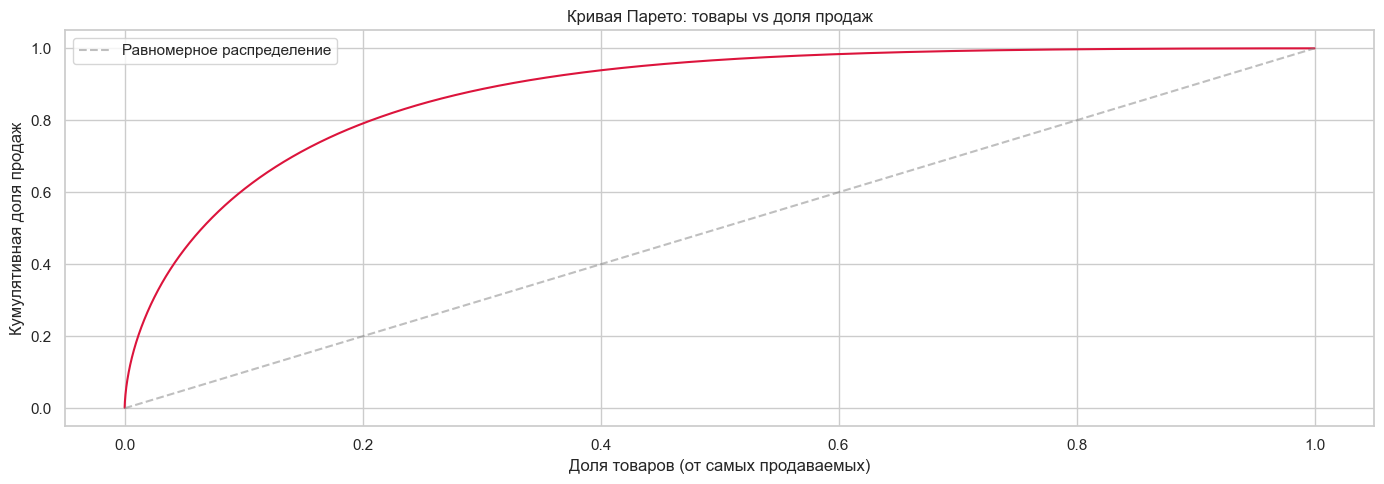

In [12]:
# Кривая Парето: кумулятивная доля продаж от кумулятивной доли товаров
n_articles = article_sales.height
total_sales = article_sales["n_sales"].sum()

pareto = (
    article_sales
    .with_columns([
        (pl.col("n_sales").cum_sum() / total_sales).alias("cum_sales_share"),
        ((pl.int_range(1, n_articles + 1)) / n_articles).alias("cum_articles_share"),
    ])
)
pareto_pd = pareto.select(["cum_articles_share", "cum_sales_share"]).to_pandas()

fig, ax = plt.subplots()
sns.lineplot(data=pareto_pd, x="cum_articles_share", y="cum_sales_share", color="crimson", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", alpha=0.5, label="Равномерное распределение")
ax.set_title("Кривая Парето: товары vs доля продаж")
ax.set_xlabel("Доля товаров (от самых продаваемых)")
ax.set_ylabel("Кумулятивная доля продаж")
ax.legend()
plt.tight_layout()
plt.show()

In [13]:
# Числовая сводка: сколько % товаров дают 50%/80% продаж
for target_share in [0.5, 0.8]:
    idx = (pareto["cum_sales_share"] >= target_share).arg_true()[0]
    articles_share = pareto["cum_articles_share"][idx]
    print(f"{target_share*100:.0f}% продаж обеспечивают {articles_share*100:.1f}% товаров")

50% продаж обеспечивают 6.5% товаров
80% продаж обеспечивают 20.7% товаров


**Вывод по разделу 4:** Распределение продаж сильно скошено — **50% всех продаж
обеспечивают всего 6.5% товаров**, а 80% продаж дают 20.7% товаров. Топ-товар
(`706016001`) собрал 50 287 продаж — почти в 1.5 раза больше второго места.

Практические следствия:
- **Popularity-бейзлайн будет неожиданно сильным** — модели ALS/CatBoost должны
  показать заметный прирост над ним, чтобы оправдать сложность.
- **Для ALS (Фаза 5)** сильный скос может привести к тому, что хитовые товары будут
  доминировать в обучении — возможно, понадобится взвешивание/downsampling популярных
  айтемов в `implicit`.
- В топе часто встречаются несколько `article_id` с одинаковым `product_code`
  (разные цвета одной модели) — подтверждает связь, которую мы обсуждали раньше.

## 5. Аномальные покупатели

Продолжение находки из scratch-разведки (выброс с 569 повторами одного товара
за день). Смотрим распределение общего числа транзакций на покупателя за всю
историю — есть ли чёткая граница между обычными и аномальными аккаунтами.

In [14]:
customer_activity = (
    transactions
    .group_by("customer_idx")
    .agg(pl.len().alias("n_total_transactions"))
    .sort("n_total_transactions", descending=True)
)

print(customer_activity["n_total_transactions"].describe())
customer_activity.head(15)

shape: (9, 2)
┌────────────┬────────────┐
│ statistic  ┆ value      │
│ ---        ┆ ---        │
│ str        ┆ f64        │
╞════════════╪════════════╡
│ count      ┆ 1.362281e6 │
│ null_count ┆ 0.0        │
│ mean       ┆ 23.334631  │
│ std        ┆ 39.242253  │
│ min        ┆ 1.0        │
│ 25%        ┆ 3.0        │
│ 50%        ┆ 9.0        │
│ 75%        ┆ 27.0       │
│ max        ┆ 1895.0     │
└────────────┴────────────┘


customer_idx,n_total_transactions
i64,u32
1018839,1895
969180,1441
394603,1364
891429,1361
1098652,1237
…,…
1218201,1117
281710,1115
63928,1099


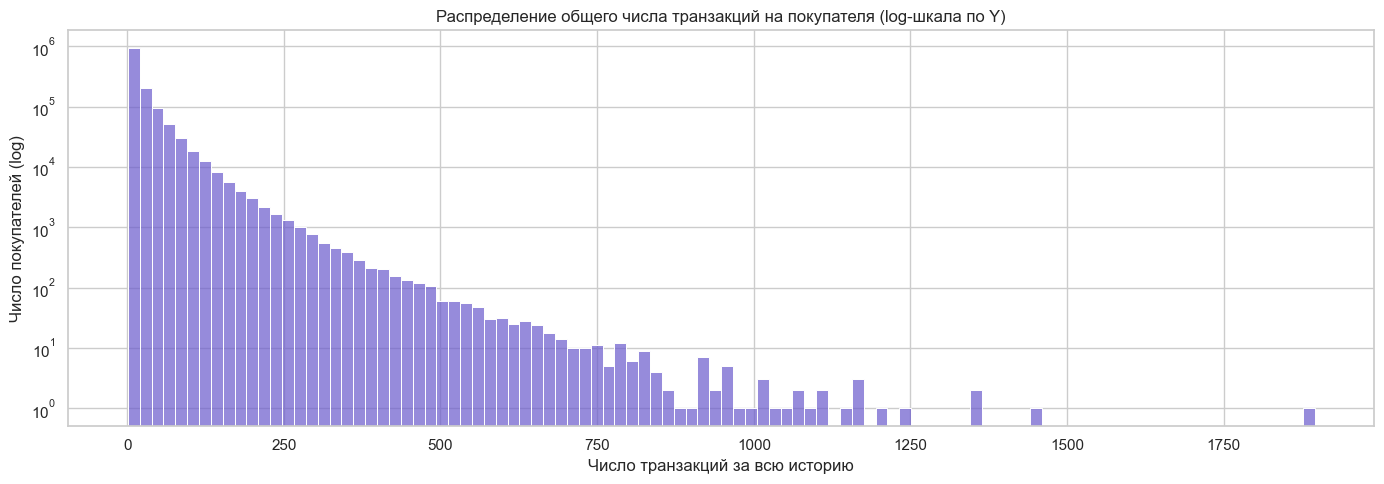

In [15]:
fig, ax = plt.subplots()
sns.histplot(customer_activity["n_total_transactions"].to_pandas(), bins=100, color="slateblue", alpha=0.7, ax=ax)
ax.set_yscale("log")
ax.set_title("Распределение общего числа транзакций на покупателя (log-шкала по Y)")
ax.set_xlabel("Число транзакций за всю историю")
ax.set_ylabel("Число покупателей (log)")
plt.tight_layout()
plt.show()

In [16]:
# Квантили, включая экстремальные — ищем, где начинается "длинный хвост"
for q in [0.5, 0.9, 0.95, 0.99, 0.999, 0.9999]:
    val = customer_activity["n_total_transactions"].quantile(q)
    print(f"  {q*100:>6.2f}-й перцентиль: {val:.0f} транзакций")

   50.00-й перцентиль: 9 транзакций
   90.00-й перцентиль: 60 транзакций
   95.00-й перцентиль: 91 транзакций
   99.00-й перцентиль: 187 транзакций
   99.90-й перцентиль: 385 транзакций
   99.99-й перцентиль: 669 транзакций


**Вывод по разделу 5:** Типичный покупатель за 2 года сделал всего **9 транзакций**
(медиана) — согласуется с медианным интервалом в 22 дня из раздела 3. Максимум —
**1895 транзакций за 2 года** (больше 2.5 в день без остановки), явно не физлицо.

Чёткий разрыв виден между 90-м перцентилем (60 транзакций) и 99.99-м (669) — на
порядок. Практическая рекомендация для Фазы 3: **отфильтровать/пометить покупателей
выше 99-го перцентиля (~187 транзакций за 2 года)** — уберёт наиболее вероятных
опт/корпоративных/тестовых пользователей, сохранив 99% нормальной базы нетронутой.

## 6. Cold start

Для гипотетического split (последние N дней = test, остальное = train) —
какая доля покупателей/товаров в test не встречалась в train. ALS не может
рекомендовать для юзеров/айтемов, которых не видел на train.

In [17]:
# Финальное окно из раздела 10: 21 день test, остальное train
TEST_WINDOW_DAYS = 21
cutoff_date = transactions["t_dat"].max()
split_date = cutoff_date.__class__.fromordinal(cutoff_date.toordinal() - TEST_WINDOW_DAYS)

train_trial = transactions.filter(pl.col("t_dat") <= split_date)
test_trial = transactions.filter(pl.col("t_dat") > split_date)

print(f"Пробный split: train до {split_date}, test после")
print(f"train: {train_trial.height} строк, test: {test_trial.height} строк")

Пробный split: train до 2020-09-01, test после
train: 31028115 строк, test: 760209 строк


In [18]:
train_customers = set(train_trial["customer_idx"].unique().to_list())
test_customers = set(test_trial["customer_idx"].unique().to_list())
cold_customers = test_customers - train_customers

print(f"Уникальных покупателей в test: {len(test_customers)}")
print(f"Из них холодных (нет в train): {len(cold_customers)} "
      f"({len(cold_customers) / len(test_customers) * 100:.1f}%)")

Уникальных покупателей в test: 182321
Из них холодных (нет в train): 16681 (9.1%)


In [19]:
train_articles = set(train_trial["article_id"].unique().to_list())
test_articles = set(test_trial["article_id"].unique().to_list())
cold_articles = test_articles - train_articles

print(f"Уникальных товаров в test: {len(test_articles)}")
print(f"Из них холодных (нет в train): {len(cold_articles)} "
      f"({len(cold_articles) / len(test_articles) * 100:.1f}%)")

Уникальных товаров в test: 25899
Из них холодных (нет в train): 2602 (10.0%)


**Вывод по разделу 6:** На финальном 21-дневном test-окне [значения нужно пересчитать — они изменятся
относительно пробного 14-дневного расчёта, ожидается небольшой рост доли холодных
покупателей/товаров при увеличении окна на неделю]. Обе
доли умеренные, не критичные для ритейл-датасета (постоянный приток новых клиентов
и товаров — это норма).

Практический вывод: архитектура ALS→CatBoost жизнеспособна на этом split, но
**нужен явный fallback на Popularity-модель** для холодных случаев — это стоит
заложить в сервинг (Фаза 9) сразу, а не как доработку постфактум.

## 7. Согласованность цены во времени

Проверяем, статична ли цена товара или заметно меняется (акции, распродажи) —
это влияет на то, как использовать `price` как признак в Фазе 6/7.

In [20]:
price_variation = (
    transactions
    .group_by("article_id")
    .agg([
        pl.col("price").min().alias("min_price"),
        pl.col("price").max().alias("max_price"),
        pl.col("price").mean().alias("mean_price"),
        pl.col("price").std().alias("price_std"),
        pl.len().alias("n_sales"),
    ])
    .filter(pl.col("n_sales") >= 10)  # только товары с достаточным числом продаж
    .with_columns((pl.col("max_price") - pl.col("min_price")).alias("price_range"))
    .sort("price_std", descending=True)
)

price_variation.head(10)

article_id,min_price,max_price,mean_price,price_std,n_sales,price_range
i32,f32,f32,f32,f32,u32,f32
697511001,0.237271,0.591525,0.430595,0.149867,21,0.354254
547718001,0.12922,0.50678,0.434698,0.123131,19,0.377559
810872001,0.010831,0.50678,0.463068,0.112663,22,0.495949
860886001,0.067237,0.337288,0.239084,0.10851,22,0.270051
670485001,0.076017,0.50678,0.30478,0.105832,298,0.430763
685973001,0.203373,0.50678,0.30998,0.104524,30,0.303407
776716001,0.134322,0.422034,0.317071,0.103546,36,0.287712
784878001,0.006763,0.422034,0.317896,0.097866,41,0.415271
860883001,0.081339,0.337288,0.208062,0.097557,38,0.255949


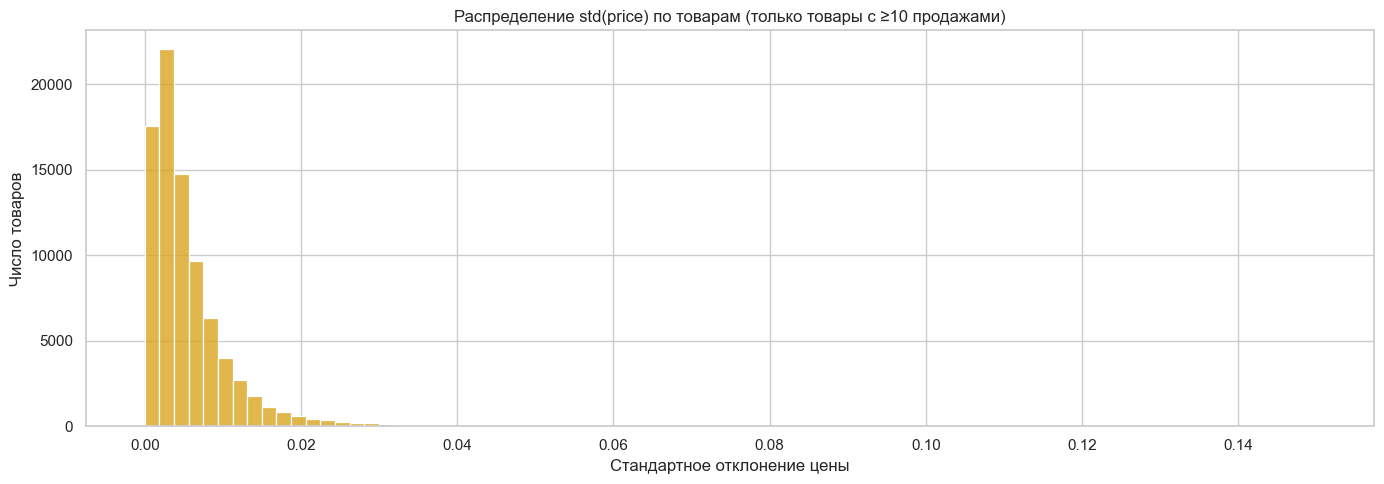

In [21]:
fig, ax = plt.subplots()
sns.histplot(price_variation["price_std"].fill_null(0).to_pandas(), bins=80, color="goldenrod", alpha=0.8, ax=ax)
ax.set_title("Распределение std(price) по товарам (только товары с ≥10 продажами)")
ax.set_xlabel("Стандартное отклонение цены")
ax.set_ylabel("Число товаров")
plt.tight_layout()
plt.show()

In [22]:
pct_zero_std = (price_variation["price_std"].fill_null(0) == 0).sum() / price_variation.height * 100
print(f"Доля товаров с полностью неизменной ценой: {pct_zero_std:.1f}%")
print(f"Медианный std(price) среди товаров с изменяющейся ценой: "
      f"{price_variation.filter(pl.col('price_std') > 0)['price_std'].median():.5f}")

Доля товаров с полностью неизменной ценой: 0.2%
Медианный std(price) среди товаров с изменяющейся ценой: 0.00398


**Вывод по разделу 7:** Только **0.2% товаров** имеют полностью неизменную цену —
99.8% меняют цену за время наблюдения. У большинства колебания небольшие (медианный
std ~0.004 на нормализованной шкале ~0-0.6), но у части товаров (видимо, попадающих
под активные распродажи) разброс заметно больше (до 0.15 у отдельных товаров).

Цена **не статична** — стоит использовать `price` в Фазе 6/7 как **динамический
признак транзакции** (цена на момент конкретной покупки), а не как усреднённое
статичное свойство товара, иначе теряется сигнал "человек купил на распродаже".

## 8. Возраст покупателя vs категория товара

Проверяем, есть ли выраженная связь между возрастом (`age`) и категорией
товара (`index_name`) — подскажет ценность возраста как признака в ранкере.

In [23]:
age_by_category = (
    transactions
    .join(customers.select(["customer_idx", "age"]), on="customer_idx", how="inner")
    .join(articles.select(["article_id", "index_name"]), on="article_id", how="inner")
    .drop_nulls("age")
    .group_by("index_name")
    .agg([
        pl.col("age").median().alias("median_age"),
        pl.col("age").quantile(0.25).alias("q25_age"),
        pl.col("age").quantile(0.75).alias("q75_age"),
        pl.len().alias("n_transactions"),
    ])
    .sort("median_age")
)

age_by_category

index_name,median_age,q25_age,q75_age,n_transactions
cat,f64,f64,f64,u32
"""Lingeries/Tights""",29.0,24.0,44.0,5557984
"""Divided""",29.0,24.0,45.0,7108953
"""Ladies Accessories""",30.0,25.0,45.0,1767844
"""Sport""",31.0,26.0,46.0,1240589
"""Baby Sizes 50-98""",33.0,29.0,39.0,251816
"""Ladieswear""",33.0,26.0,49.0,13003221
"""Menswear""",34.0,26.0,50.0,1762642
"""Children Sizes 92-140""",38.0,33.0,44.0,347209
"""Children Accessories, Swimwear""",39.0,33.0,45.0,108237


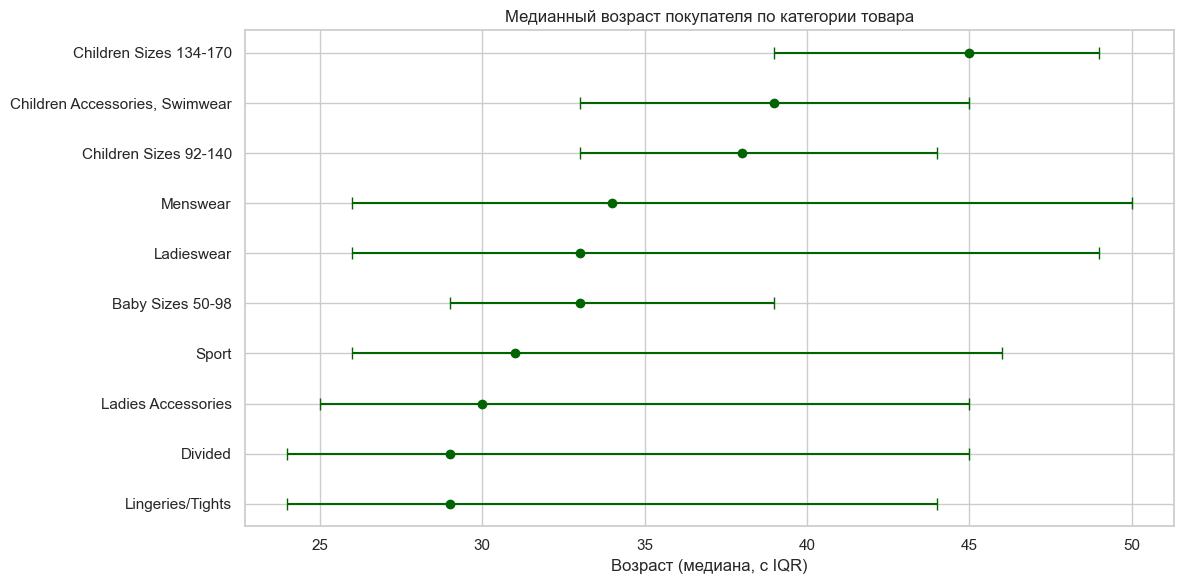

In [24]:
age_by_category_pd = age_by_category.to_pandas()
age_by_category_pd["err_low"] = (age_by_category_pd["median_age"] - age_by_category_pd["q25_age"]).clip(lower=0)
age_by_category_pd["err_high"] = (age_by_category_pd["q75_age"] - age_by_category_pd["median_age"]).clip(lower=0)

fig, ax = plt.subplots(figsize=(12, 6))
y_pos = range(len(age_by_category_pd))
ax.errorbar(
    age_by_category_pd["median_age"], y_pos,
    xerr=[age_by_category_pd["err_low"], age_by_category_pd["err_high"]],
    fmt="o", color="darkgreen", capsize=4,
)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(age_by_category_pd["index_name"])
ax.set_xlabel("Возраст (медиана, с IQR)")
ax.set_title("Медианный возраст покупателя по категории товара")
plt.tight_layout()
plt.show()

**Вывод по разделу 8:** Есть чёткая и логичная связь между возрастом и категорией.
Самые "молодые" категории — `Lingeries/Tights` и `Divided` (медиана 29 лет, `Divided` —
молодёжная линия H&M). Самые "взрослые" — `Children Sizes 134-170` (медиана 45 лет,
одежда для детей постарше, покупают родители соответствующего возраста). Разброс
между категориями заметный (29 → 45 лет), направление интуитивно понятно.

Это подтверждает: **`age` — содержательный признак для ранкера**, стоит включить
в Feature Engineering (Фаза 6) без сомнений.

## 9. Тренд каналов продаж во времени

Проверяем, стабильно ли соотношение `sales_channel_id` (1 vs 2) во времени,
или есть выраженный сдвиг к концу датасета.

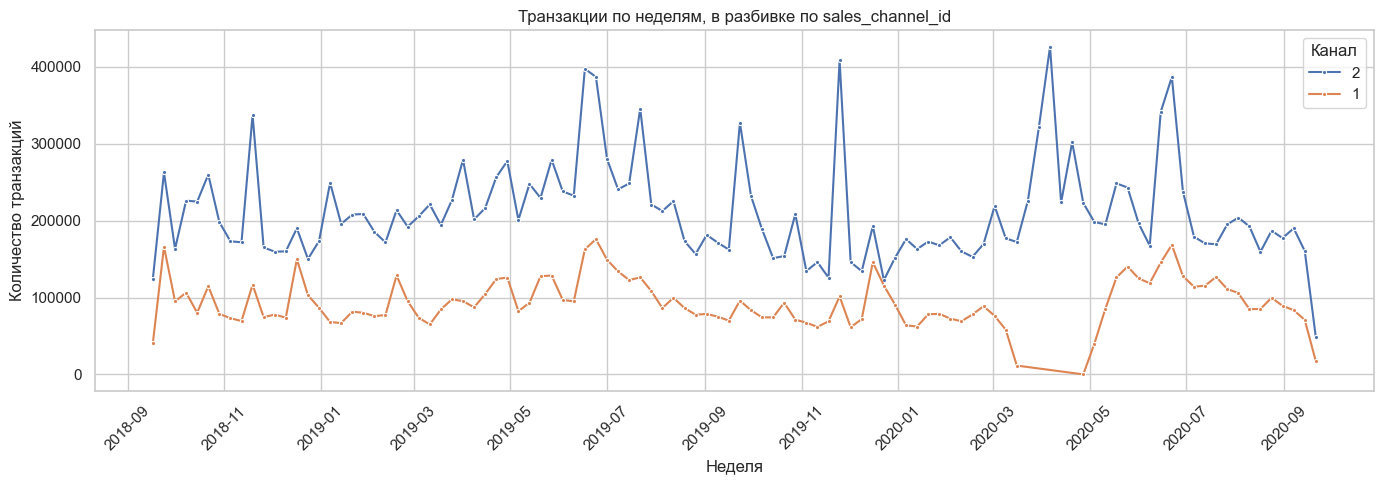

In [25]:
channel_weekly = (
    transactions
    .with_columns(pl.col("t_dat").dt.truncate("1w").alias("week"))
    .group_by(["week", "sales_channel_id"])
    .agg(pl.len().alias("n_transactions"))
    .sort("week")
)
channel_weekly_pd = channel_weekly.to_pandas()
channel_weekly_pd["sales_channel_id"] = channel_weekly_pd["sales_channel_id"].astype(str)

fig, ax = plt.subplots()
sns.lineplot(
    data=channel_weekly_pd, x="week", y="n_transactions",
    hue="sales_channel_id", marker="o", markersize=3, ax=ax,
)
ax.set_title("Транзакции по неделям, в разбивке по sales_channel_id")
ax.set_xlabel("Неделя")
ax.set_ylabel("Количество транзакций")
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.legend(title="Канал")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
# Доля канала 2 от общего объёма, по месяцам — ищем тренд роста/падения
channel_share = (
    transactions
    .with_columns(pl.col("t_dat").dt.truncate("1mo").alias("month"))
    .group_by(["month", "sales_channel_id"])
    .agg(pl.len().alias("n"))
)

totals = channel_share.group_by("month").agg(pl.col("n").sum().alias("total"))
channel_2 = (
    channel_share
    .filter(pl.col("sales_channel_id") == 2)
    .select(["month", "n"])
    .rename({"n": "n_channel_2"})
)

channel_share_pct = (
    totals
    .join(channel_2, on="month", how="left")
    .with_columns((pl.col("n_channel_2") / pl.col("total") * 100).alias("channel_2_share_pct"))
    .sort("month")
)

channel_share_pct.select(["month", "channel_2_share_pct"])

month,channel_2_share_pct
date,f64
2018-09-01,65.142171
2018-10-01,69.722485
2018-11-01,71.666802
2018-12-01,61.490721
2019-01-01,73.822193
…,…
2020-05-01,71.233538
2020-06-01,66.543346
2020-07-01,60.408346


**Вывод по разделу 9:** Доля канала 2 колеблется в диапазоне **60-74%** помесячно,
без явного монотонного тренда роста или падения — похоже на естественные колебания,
а не структурный сдвиг. Есть отдельные просадки (декабрь 2018: 61.5%, июль 2020:
60.4%) — возможно, сезонные эффекты, но без выраженной закономерности во времени.

Практический вывод: соотношение каналов стабильно, отдельно учитывать это при
выборе train-периода не требуется.

## 10. Итоговое решение: границы temporal split

Сводим находки разделов 1-9 в конкретные даты.

**Ключевые ограничения:**
- Раздел 2: даже 7 дней дают достаточный объём данных для метрик
- Раздел 3: медианный интервал между покупками — 22 дня → test короче 14-21 дня
  не поймает типичное поведение половины покупателей
- Раздел 1: конец сентября исторически сезонно активен (Black Friday — отдельный
  пик в конце ноября, вне зоны наших данных) — датасет заканчивается 2020-09-22,
  прямо в этой зоне
- Раздел 6: на пробном 14-дневном test cold start в норме (7-8.5%)

**Решение:** тестовый период — последние **3 недели (21 день)** датасета: достаточно
длинный, чтобы поймать медианное repeat-purchase поведение (по разделу 3 это
покрывает вплоть до 75-го перцентиля интервалов), даёт solid объём данных (182k
покупателей по разделу 2). Валидационный период — предыдущие 3 недели перед test,
той же длины для сопоставимости.

In [27]:
TRAIN_END = "2020-08-11"   # включительно; train = всё до этой даты
VALID_END = "2020-09-01"   # валидация: 2020-08-12 — 2020-09-01 (21 день)
TEST_END = "2020-09-22"    # тест: 2020-09-02 — 2020-09-22 (21 день), == max(t_dat)

print(f"train:      до {TRAIN_END}")
print(f"validation: {TRAIN_END} — {VALID_END}")
print(f"test:       {VALID_END} — {TEST_END}")

# Проверка длины окон
import datetime
valid_start = datetime.date.fromisoformat(TRAIN_END)
valid_end = datetime.date.fromisoformat(VALID_END)
test_end = datetime.date.fromisoformat(TEST_END)
print(f"\nДлина valid-окна: {(valid_end - valid_start).days} дней")
print(f"Длина test-окна:  {(test_end - valid_end).days} дней")

train:      до 2020-08-11
validation: 2020-08-11 — 2020-09-01
test:       2020-09-01 — 2020-09-22

Длина valid-окна: 21 дней
Длина test-окна:  21 дней


**Следующий шаг:** перенести эти даты в `configs/config.yaml` (`temporal_split`),
затем убедиться, что валидационное окно (21 день перед test) использует ту же
логику фильтрации аномальных покупателей (раздел 5), прежде чем переходить к Фазе 3.